<a href="https://colab.research.google.com/github/naabiiill/Machine_Learning/blob/main/Diabetes_Detection_System_w10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    flo

In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

logistic_model = LogisticRegression(max_iter=1000)
knn_model = KNeighborsClassifier(n_neighbors=5)
tree_model = DecisionTreeClassifier(random_state=42)

# Train Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

# Train KNN
knn_model.fit(X_train_scaled, y_train)

# Train Decision Tree
tree_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [7]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
logistic_pred = logistic_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test)

# Logistic Regression
print("===== Logistic Regression =====")
print("Confusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall:", recall_score(y_test, logistic_pred))
print("F1 Score:", f1_score(y_test, logistic_pred))

# KNN
print("\n===== KNN =====")
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred))

# Decision Tree
print("\n===== Decision Tree =====")
print("Confusion Matrix:")
print(confusion_matrix(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

===== Logistic Regression =====
Confusion Matrix:
[[82 18]
 [26 28]]
Precision: 0.6086956521739131
Recall: 0.5185185185185185
F1 Score: 0.56

===== KNN =====
Confusion Matrix:
[[80 20]
 [26 28]]
Precision: 0.5833333333333334
Recall: 0.5185185185185185
F1 Score: 0.5490196078431373

===== Decision Tree =====
Confusion Matrix:
[[85 15]
 [27 27]]
Precision: 0.6428571428571429
Recall: 0.5
F1 Score: 0.5625


Logistic Regression AUC: 0.8229629629629629
KNN AUC: 0.7404629629629629
Decision Tree AUC: 0.6749999999999999


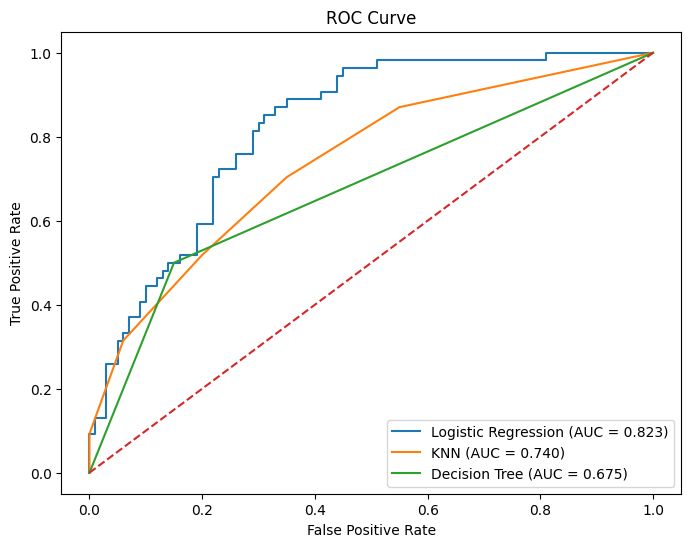

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
tree_prob = tree_model.predict_proba(X_test)[:, 1]

# ROC curves
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_prob)

# AUC
logistic_auc = roc_auc_score(y_test, logistic_prob)
knn_auc = roc_auc_score(y_test, knn_prob)
tree_auc = roc_auc_score(y_test, tree_prob)

print("Logistic Regression AUC:", logistic_auc)
print("KNN AUC:", knn_auc)
print("Decision Tree AUC:", tree_auc)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(logistic_fpr, logistic_tpr, label=f"Logistic Regression (AUC = {logistic_auc:.3f})")
plt.plot(knn_fpr, knn_tpr, label=f"KNN (AUC = {knn_auc:.3f})")
plt.plot(tree_fpr, tree_tpr, label=f"Decision Tree (AUC = {tree_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, tree_pred)
    ],
    "AUC": [
        logistic_auc,
        knn_auc,
        tree_auc
    ]
})

print(results.round(4))

                 Model  Precision  Recall  F1 Score     AUC
0  Logistic Regression     0.6087  0.5185    0.5600  0.8230
1                  KNN     0.5833  0.5185    0.5490  0.7405
2        Decision Tree     0.6429  0.5000    0.5625  0.6750
